In [1]:
import sys
import json
import os
from dotenv import load_dotenv

# 导入grid2op必要组件
import grid2op
from grid2op.PlotGrid import PlotMatplot
from grid2op.Action import PlayableAction
from grid2op.Rules import AlwaysLegal
# from grid2op.Parameters import Parameters

from langchain_deepseek import ChatDeepSeek
from langgraph.prebuilt import create_react_agent
from langgraph.prebuilt import ToolExecutor

# 导入全局上下文和工具函数
from global_context import env_manager
from src.utils import get_logger

# 导入新的模块化组件
from actions.wrapper import ActionFactory, ActionWrapper
from observations.provider import observation_provider

# 以下为在notebook中测试使用
import numpy as np
from typing import Dict, List, Any, Optional

# 导入工具函数
from tools.grid2op_tools import (
    # 动作创建工具
    create_gen_set_bus,
    create_load_set_bus,
    create_line_or_set_bus,
    create_line_ex_set_bus,
    create_storage_set_bus,
    create_line_set_status, 
    create_redispatch,
    create_cancel_redispatch,
    create_curtail,
    create_storage_p,
    
    # 动作执行工具
    execute_action,
    combine_actions,
    execute_combined_action,
    
    # 观测获取工具
    get_observation,
    get_topology_snapshot,
    get_power_flow_snapshot,
    get_dispatch_snapshot,
    get_time_info,
    get_env_parameters
)

In [2]:
# 设置环境名称与规则
env_name = "l2rpn_case14_sandbox"
# env_name = "l2rpn_wcci_2022" # 有存储单元

rules = AlwaysLegal()

# 初始化日志
logger = get_logger(__name__)

# 注意：不再创建新的环境管理器和动作工厂实例，而是使用全局导入的实例
# env_manager和action_factory已经从global_context和wrapper中导入

try:
    from lightsim2grid import LightSimBackend
    bk_cls = LightSimBackend
    logger.info("成功导入 LightSimBackend 用于更快的后端计算。")
except ImportError as exc:
    logger.warning(f"导入 LightSimBackend 时发生错误：{exc}，将使用 PandaPowerBackend 作为后备方案。")
    from grid2op.Backend import PandaPowerBackend
    bk_cls = PandaPowerBackend

# 生成唯一环境标识符
env_id = "test1"

# 创建环境
env = grid2op.make(env_name,
                   action_class=PlayableAction,
                   gamerules_class=rules,
                   backend=bk_cls())
logger.info(f"环境 '{env_name}' 创建成功，使用后端: {bk_cls.__name__}。")

try:
    # 使用普通方法注册环境（不再使用上下文管理器）
    env_manager.register_env(env_id, env)
    logger.info(f"环境 '{env_name}' 注册成功。")

    # 重置环境并获取初始观察值
    obs = env.reset()

    # 注册初始观察值
    env_manager.record_observation(env_id, obs)
    logger.info(f"环境 '{env_id}' 注册成功并获取初始观察值。")
except Exception as e:
    logger.error(f"环境操作失败，错误信息：{e}")
    sys.exit(1)

[2025-04-08 16:21:39,998] [__main__] [76810413.py(16)] [INFO] 成功导入 LightSimBackend 用于更快的后端计算。
[2025-04-08 16:21:40,395] [pandapower.convert_format] [convert_format.py(102)] [INFO] These dtypes could not be corrected: {'trafo': ['tap_min', 'tap_max']}
[2025-04-08 16:21:41,396] [__main__] [76810413.py(30)] [INFO] 环境 'l2rpn_case14_sandbox' 创建成功，使用后端: LightSimBackend。
[2025-04-08 16:21:41,398] [__main__] [76810413.py(35)] [INFO] 环境 'l2rpn_case14_sandbox' 注册成功。
[2025-04-08 16:21:41,567] [__main__] [76810413.py(42)] [INFO] 环境 'test1' 注册成功并获取初始观察值。


In [3]:
# 加载 .env 文件中的环境变量
load_dotenv()

# 初始化语言模型
model = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0.7
)


# 绑定工具

# 配置工具执行器
tools = [
    # 动作创建工具
    create_gen_set_bus,
    create_load_set_bus,
    create_line_or_set_bus,
    create_line_ex_set_bus,
    create_storage_set_bus,
    create_line_set_status, 
    create_redispatch,
    create_cancel_redispatch,
    create_curtail,
    create_storage_p,
    
    # 动作执行工具
    execute_action,
    combine_actions,
    execute_combined_action,
    
    # 观测获取工具
    get_observation,
    get_topology_snapshot,
    get_power_flow_snapshot,
    get_dispatch_snapshot,
    get_time_info,
    get_env_parameters
]


In [4]:
# 使用预构筑的ReAct agent绘制图

graph = create_react_agent(model, tools=tools)

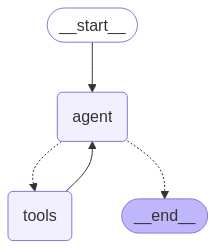

In [5]:
# 在notebook中显示图（仅在notebook环境下可用）

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
# 生成信息流

def print_stream(stream):
    for s in stream:
        message = s["messages"][-1]
        if isinstance(message, tuple):
            print(message)
        else:
            message.pretty_print()

In [7]:
#invoke
inputs = {"messages": [("user",
                        '''请执行以下电网操作任务，并描述每一步你的思路：

1. 先获取"test1"环境中所有发电机的当前发电功率和所有输电线路的连接状态。

2. 在一个时间步内完成以下多个操作：
   - 将0号发电机的发电功率增加2.5MW
   - 将1号发电机的发电功率减少1.5MW
   - 将2号线路的输入和输出端从母线1切换到母线2
   - 断开4号线路的连接

3. 操作完成后，再次获取环境的状态，并分析哪些参数发生了变化，以及变化是否符合预期。

请确保使用适当的工具函数来完成这些任务，并解释你选择特定工具的原因。如果有多种方法可以完成同一任务，请说明你选择的方法及其优势。''')]}

print_stream(graph.stream(inputs, stream_mode="values"))

================================ Human Message =================================

请执行以下电网操作任务，并描述每一步你的思路：

1. 先获取"test1"环境中所有发电机的当前发电功率和所有输电线路的连接状态。

2. 在一个时间步内完成以下多个操作：
   - 将0号发电机的发电功率增加2.5MW
   - 将1号发电机的发电功率减少1.5MW
   - 将2号线路的输入和输出端从母线1切换到母线2
   - 断开4号线路的连接

3. 操作完成后，再次获取环境的状态，并分析哪些参数发生了变化，以及变化是否符合预期。

请确保使用适当的工具函数来完成这些任务，并解释你选择特定工具的原因。如果有多种方法可以完成同一任务，请说明你选择的方法及其优势。


[2025-04-08 16:22:05,502] [httpx] [_client.py(1025)] [INFO] HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"
[2025-04-08 16:22:31,582] [observations.provider] [provider.py(36)] [INFO] 获取观测数据: env_id=test1, component=gen_p, element_id=None
[2025-04-08 16:22:31,587] [observations.provider] [provider.py(60)] [INFO] 成功获取 gen_p 数据
[2025-04-08 16:22:31,588] [observations.provider] [provider.py(36)] [INFO] 获取观测数据: env_id=test1, component=line_status, element_id=None
[2025-04-08 16:22:31,591] [observations.provider] [provider.py(60)] [INFO] 成功获取 line_status 数据
[2025-04-08 16:22:31,714] [httpx] [_client.py(1025)] [INFO] HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


================================== Ai Message ==================================

### 思路与步骤

#### 1. 获取当前环境状态
首先，我需要获取"test1"环境中所有发电机的当前发电功率和所有输电线路的连接状态。这将作为后续操作的基准，并帮助验证操作后的变化。

- **工具选择**：
  - `get_observation`：用于获取特定组件的观测数据。
    - 对于发电机的发电功率，使用`component="gen_p"`。
    - 对于输电线路的连接状态，使用`component="line_status"`。

#### 2. 执行多个操作
在一个时间步内完成以下操作：
- **发电机功率调整**：
  - 0号发电机增加2.5MW。
  - 1号发电机减少1.5MW。
  - **工具选择**：
    - `create_redispatch`：用于创建发电机重调度动作。优势是可以精确指定发电机ID和调整量。
- **线路母线切换**：
  - 将2号线路的输入和输出端从母线1切换到母线2。
  - **工具选择**：
    - `create_line_or_set_bus`和`create_line_ex_set_bus`：分别用于设置线路的起始端和终止端母线状态。优势是可以独立控制线路的两个端点。
- **断开线路**：
  - 断开4号线路的连接。
  - **工具选择**：
    - `create_line_set_status`：用于设置线路状态（断开或连接）。优势是直接控制线路的开关状态。

#### 3. 组合并执行动作
为了在一个时间步内完成所有操作，需要将这些动作组合成一个动作。
- **工具选择**：
  - `combine_actions`：将多个动作组合成一个动作ID。
  - `execute_action`：执行组合后的动作。

#### 4. 获取操作后的状态
操作完成后，再次获取发电机的发电功率和线路的连接状态，并与操作前的状态进行对比分析。

---

### 执行步骤

#### 第一步：获取当前状态
我将先获取发电机的发电功率和线路的连接状态。
Tool Calls:
  get_observation

[2025-04-08 16:22:51,424] [actions.wrapper] [wrapper.py(146)] [INFO] 已添加发电机重调度操作: gen_id=[0, 1], amount=[2.5, -1.5]
[2025-04-08 16:22:51,431] [actions.wrapper] [wrapper.py(83)] [INFO] 已添加线路起始端母线设置操作: line_id=[2], bus_status=[2]
[2025-04-08 16:22:51,434] [actions.wrapper] [wrapper.py(98)] [INFO] 已添加线路终止端母线设置操作: line_id=[2], bus_status=[2]
[2025-04-08 16:22:51,438] [actions.wrapper] [wrapper.py(131)] [INFO] 已添加线路状态设置操作: line_id=[4], line_status=[-1]
[2025-04-08 16:22:51,591] [httpx] [_client.py(1025)] [INFO] HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


================================== Ai Message ==================================

### 当前环境状态

#### 发电机的发电功率 (gen_p)
- 0号发电机: 81.40 MW
- 1号发电机: 79.30 MW
- 2号发电机: 5.30 MW
- 3号发电机: 0.00 MW
- 4号发电机: 0.00 MW
- 5号发电机: 82.25 MW

#### 输电线路的连接状态 (line_status)
所有线路（0号到19号）当前均为连接状态（`true`）。

---

### 第二步：执行多个操作
接下来，我将创建以下动作：
1. 调整发电机功率：
   - 0号发电机增加2.5 MW。
   - 1号发电机减少1.5 MW。
2. 切换2号线路的母线：
   - 起始端和终止端均从母线1切换到母线2。
3. 断开4号线路。

#### 创建动作
我将分别创建这些动作，然后组合成一个动作。
Tool Calls:
  create_redispatch (call_0_ede6cb59-ac8f-4bac-96a6-4b0ddf651b59)
 Call ID: call_0_ede6cb59-ac8f-4bac-96a6-4b0ddf651b59
  Args:
    env_id: test1
    gen_id: [0, 1]
    amount: [2.5, -1.5]
  create_line_or_set_bus (call_1_82a92a48-0f41-4faa-a1f3-e4d98b7ce78b)
 Call ID: call_1_82a92a48-0f41-4faa-a1f3-e4d98b7ce78b
  Args:
    env_id: test1
    line_id: [2]
    bus_status: [2]
  create_line_ex_set_bus (call_2_5080ae48-33f5-4b87-b73d-264f51eeff3b)
 Call ID: call_2_5080ae48-33f5-4b87-b73d-264f51eeff3b
  Args:
    env_id: test1
    line_

...

================================== Ai Message ==================================

### 动作创建成功

已成功创建以下动作：
1. **发电机重调度**：
   - 动作ID: `test1_redispatch_138046267616160`
   - 操作: 0号发电机增加2.5 MW，1号发电机减少1.5 MW。
2. **线路起始端母线设置**：
   - 动作ID: `test1_line_or_set_bus_138046267619280`
   - 操作: 将2号线路的起始端切换到母线2。
3. **线路终止端母线设置**：
   - 动作ID: `test1_line_ex_set_bus_138046267620000`
   - 操作: 将2号线路的终止端切换到母线2。
4. **线路状态设置**：
   - 动作ID: `test1_line_set_status_138046267616352`
   - 操作: 断开4号线路。

---

### 组合并执行动作
接下来，我将这些动作组合成一个动作并执行。
Tool Calls:
  combine_actions (call_0_e1bee2d6-7152-4f83-a6ae-fbf7d44c9349)
 Call ID: call_0_e1bee2d6-7152-4f83-a6ae-fbf7d44c9349
  Args:
    action_ids: ['test1_redispatch_138046267616160', 'test1_line_or_set_bus_138046267619280', 'test1_line_ex_set_bus_138046267620000', 'test1_line_set_status_138046267616352']
================================= Tool Message =================================
Name: combine_actions

{"status": "success", "message": "成功组合动作", "action_id": "test1_co

[2025-04-08 16:23:15,698] [actions.wrapper] [wrapper.py(283)] [INFO] 动作执行成功
[2025-04-08 16:23:15,854] [httpx] [_client.py(1025)] [INFO] HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


================================== Ai Message ==================================

### 动作组合成功

已成功将以下动作组合为一个动作：
- 组合动作ID: `test1_combined_138046267616160`

---

### 执行组合动作
现在，我将执行这个组合动作。
Tool Calls:
  execute_action (call_0_1c8652d7-90f4-4cc8-9bca-02530e03448e)
 Call ID: call_0_1c8652d7-90f4-4cc8-9bca-02530e03448e
  Args:
    action_id: test1_combined_138046267616160
================================= Tool Message =================================
Name: execute_action

{'status': 'success', 'message': '动作执行成功', 'observation': <grid2op.Space.GridObjects.CompleteObservation_l2rpn_case14_sandbox object at 0x7d8d66bf3620>, 'reward': -10.0, 'done': True, 'info': {'disc_lines': array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1], dtype=int32), 'is_illegal': False, 'is_ambiguous': False, 'is_dispatching_illegal': False, 'is_illegal_reco': False, 'reason_alarm_illegal': None, 'reason_alert_illegal': None, 'opponent_attack_line': None, 'opponent_attack_su

[2025-04-08 16:23:26,470] [observations.provider] [provider.py(36)] [INFO] 获取观测数据: env_id=test1, component=gen_p, element_id=None
[2025-04-08 16:23:26,473] [observations.provider] [provider.py(60)] [INFO] 成功获取 gen_p 数据
[2025-04-08 16:23:26,477] [observations.provider] [provider.py(36)] [INFO] 获取观测数据: env_id=test1, component=line_status, element_id=None
[2025-04-08 16:23:26,479] [observations.provider] [provider.py(60)] [INFO] 成功获取 line_status 数据
[2025-04-08 16:23:26,638] [httpx] [_client.py(1025)] [INFO] HTTP Request: POST https://api.deepseek.com/v1/chat/completions "HTTP/1.1 200 OK"


================================== Ai Message ==================================

### 动作执行结果

组合动作已成功执行，以下是执行结果的摘要：
- **状态**: 成功
- **奖励**: -10.0
- **是否完成**: 是
- **信息**:
  - 没有非法操作或歧义操作。
  - 检测到电力潮流计算中的问题（非连通电网），但动作本身是合法的。

---

### 第三步：获取操作后的状态
为了验证操作的效果，我将再次获取发电机的发电功率和线路的连接状态。
Tool Calls:
  get_observation (call_0_e9f3fb23-2af5-4128-ba2e-eacf275de20e)
 Call ID: call_0_e9f3fb23-2af5-4128-ba2e-eacf275de20e
  Args:
    env_id: test1
    component: gen_p
  get_observation (call_1_ccdeeea9-da92-481a-9c76-87fc84ddae79)
 Call ID: call_1_ccdeeea9-da92-481a-9c76-87fc84ddae79
  Args:
    env_id: test1
    component: line_status
================================= Tool Message =================================
Name: get_observation

{"status": "success", "message": "成功获取 line_status 数据", "data": [false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false, false]}
================================== Ai Message =================